In [32]:
import pandas as pd
import os
import numpy as np
from sqlalchemy import text , create_engine
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
engine = create_engine(
    f"mysql+mysqlconnector://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}@{os.environ['DB_HOST']}/{os.environ['DB_NAME']}"
)

with engine.connect() as conn:
    result = conn.execute(text("SHOW TABLES"))
    tables = [row[0] for row in result]

print("Total Tables:", len(tables))
print("Table Names:")
for table in tables:
    print("-", table)


Total Tables: 2
Table Names:
- clean_dataset
- rapido_july2025_data


In [34]:
for table in tables:
    #    print(f"\n Table: {table}")
       query = text(f"SELECT COUNT(*) FROM {table}")
       df = pd.read_sql_query(query, engine)
       print(f"{table}", df.iloc[0,0])
       display(pd.read_sql(f"SELECT * FROM {table} LIMIT 5", engine))

clean_dataset 30000


,Booking_Status,Booking_Value,Pickup_Location,Drop_Location,Ride_Distance(km),Ride_Time(min),Date,Time,Vehicle_Type,Payment_Method,...,Incomplete_Rides_Reason,Total_Bookings,Canceled_Bookings,Canceled_Percentage,V_TAT,C_TAT,current_date_,hour,day,day_name
0,Completed,170.39,Pune,Delhi,2.74,42,2025-07-02,09:43,Bike,UPI,...,Ride Complate,998,122,12.22,19,27,2,9,2,Wednesday
1,Incomplete,131.04,Chennai,Hyderabad,22.15,20,2025-07-09,17:34,Auto,Cash,...,Driver delayed,986,119,12.07,25,12,9,17,2,Wednesday
2,Completed,242.19,Delhi,Bengaluru,11.95,46,2025-07-13,23:54,Bike,Card,...,Ride Complate,972,114,11.73,18,25,13,23,6,Sunday
3,Completed,78.18,Pune,Hyderabad,9.08,24,2025-07-27,17:41,Bike,Wallet,...,Ride Complate,961,112,11.65,11,6,27,17,6,Sunday
4,Completed,159.33,Chennai,Bengaluru,22.97,40,2025-07-22,22:52,Bike,Cash,...,Ride Complate,963,115,11.94,22,25,22,22,1,Tuesday


rapido_july2025_data 30000


,Booking_ID,Booking_Status,Booking_Value,Customer_ID,Driver_ID,Pickup_Location,Drop_Location,Ride_Distance(km),Ride_Time(min),Date,...,Driver_Rating,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Total_Bookings,Canceled_Bookings,Canceled_Percentage,V_TAT,C_TAT
0,RAP20250700001,Completed,170.39,CUST_2824,DR_902,Pune,Delhi,2.74,42,2025-07-02,...,4.3,0,0,0,,998,122,12.22,19,27
1,RAP20250700002,Incomplete,131.04,CUST_1409,DR_915,Chennai,Hyderabad,22.15,20,2025-07-09,...,4.9,0,0,1,Driver delayed,986,119,12.07,25,12
2,RAP20250700003,Completed,242.19,CUST_5506,DR_938,Delhi,Bengaluru,11.95,46,2025-07-13,...,4.7,0,0,0,,972,114,11.73,18,25
3,RAP20250700004,Completed,78.18,CUST_5012,DR_213,Pune,Hyderabad,9.08,24,2025-07-27,...,4.0,0,0,0,,961,112,11.65,11,6
4,RAP20250700005,Completed,159.33,CUST_4657,DR_783,Chennai,Bengaluru,22.97,40,2025-07-22,...,3.0,0,0,0,,963,115,11.94,22,25


In [35]:
df = pd.read_sql_query(text("""select * from clean_dataset"""),engine)

In [36]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Booking_Value,30000.0,139.906285,30.0,84.9175,139.995,195.08,249.99,63.552718
Ride_Distance(km),30000.0,13.198759,1.5,7.31,13.15,19.02,25.0,6.787089
Ride_Time(min),30000.0,32.1625,5.0,18.0,32.0,46.0,59.0,15.878697
Date,30000,2025-07-15 23:18:23.040000,2025-07-01 00:00:00,2025-07-08 00:00:00,2025-07-16 00:00:00,2025-07-24 00:00:00,2025-07-31 00:00:00,NaN
Customer_Rating,30000.0,4.00556,3.0,3.5,4.0,4.5,5.0,0.577114
Driver_Rating,30000.0,3.997477,3.0,3.5,4.0,4.5,5.0,0.580179
Canceled_Rides_by_Customer,30000.0,0.070433,0.0,0.0,0.0,0.0,1.0,0.25588
Canceled_Rides_by_Driver,30000.0,0.0482,0.0,0.0,0.0,0.0,1.0,0.214192
Incomplete_Rides,30000.0,0.06,0.0,0.0,0.0,0.0,1.0,0.237491
Total_Bookings,30000.0,968.386733,906.0,953.0,969.0,987.0,1009.0,24.849601


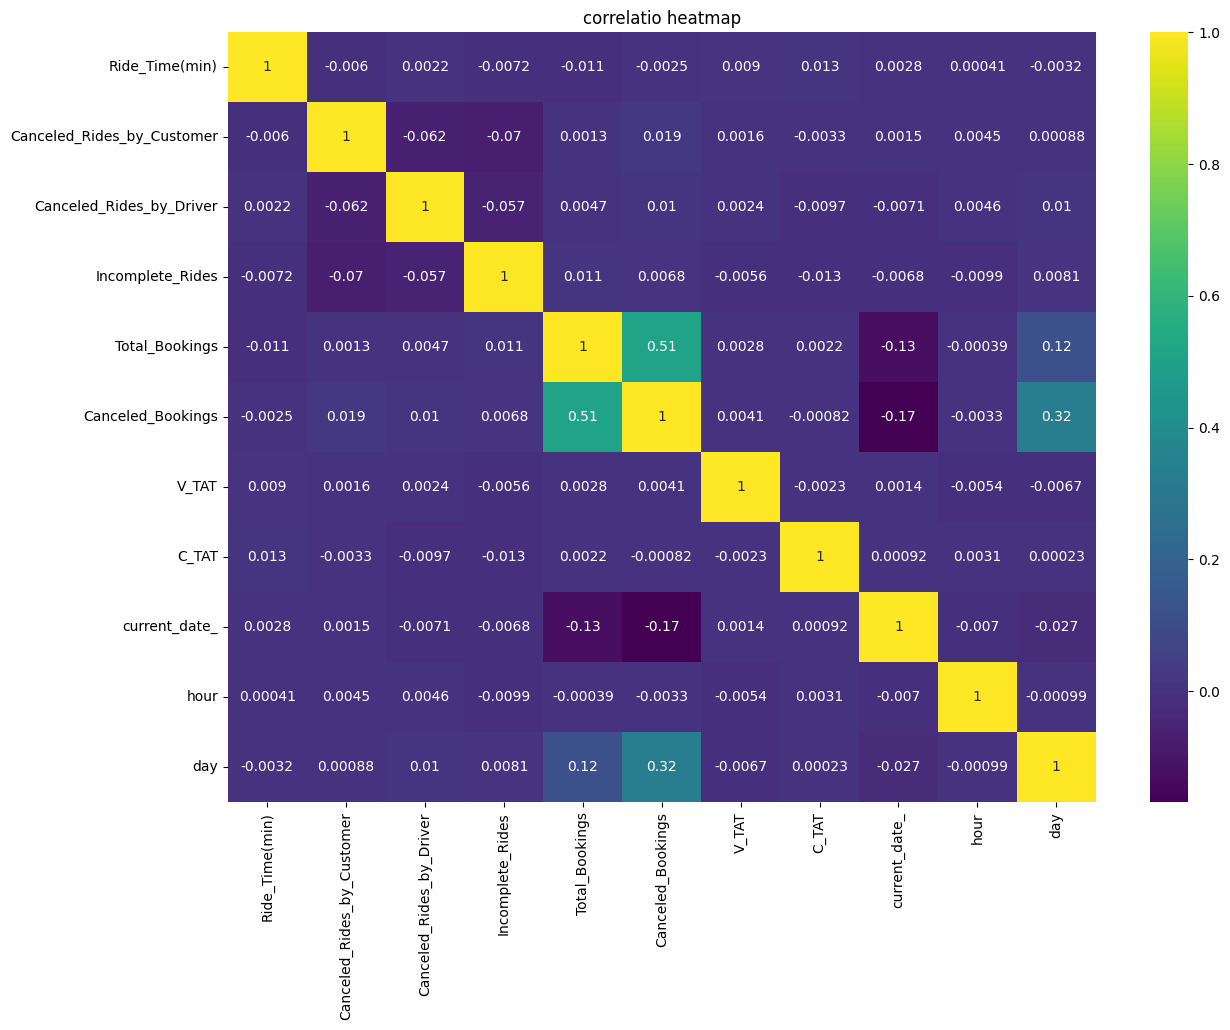

In [37]:
numeric_cols = df.select_dtypes(include=['int64','float32'])
plt.figure(figsize=(14,10))
sns.heatmap(numeric_cols.corr() , annot=True ,cmap="viridis" )
plt.title("correlatio heatmap")
plt.show()

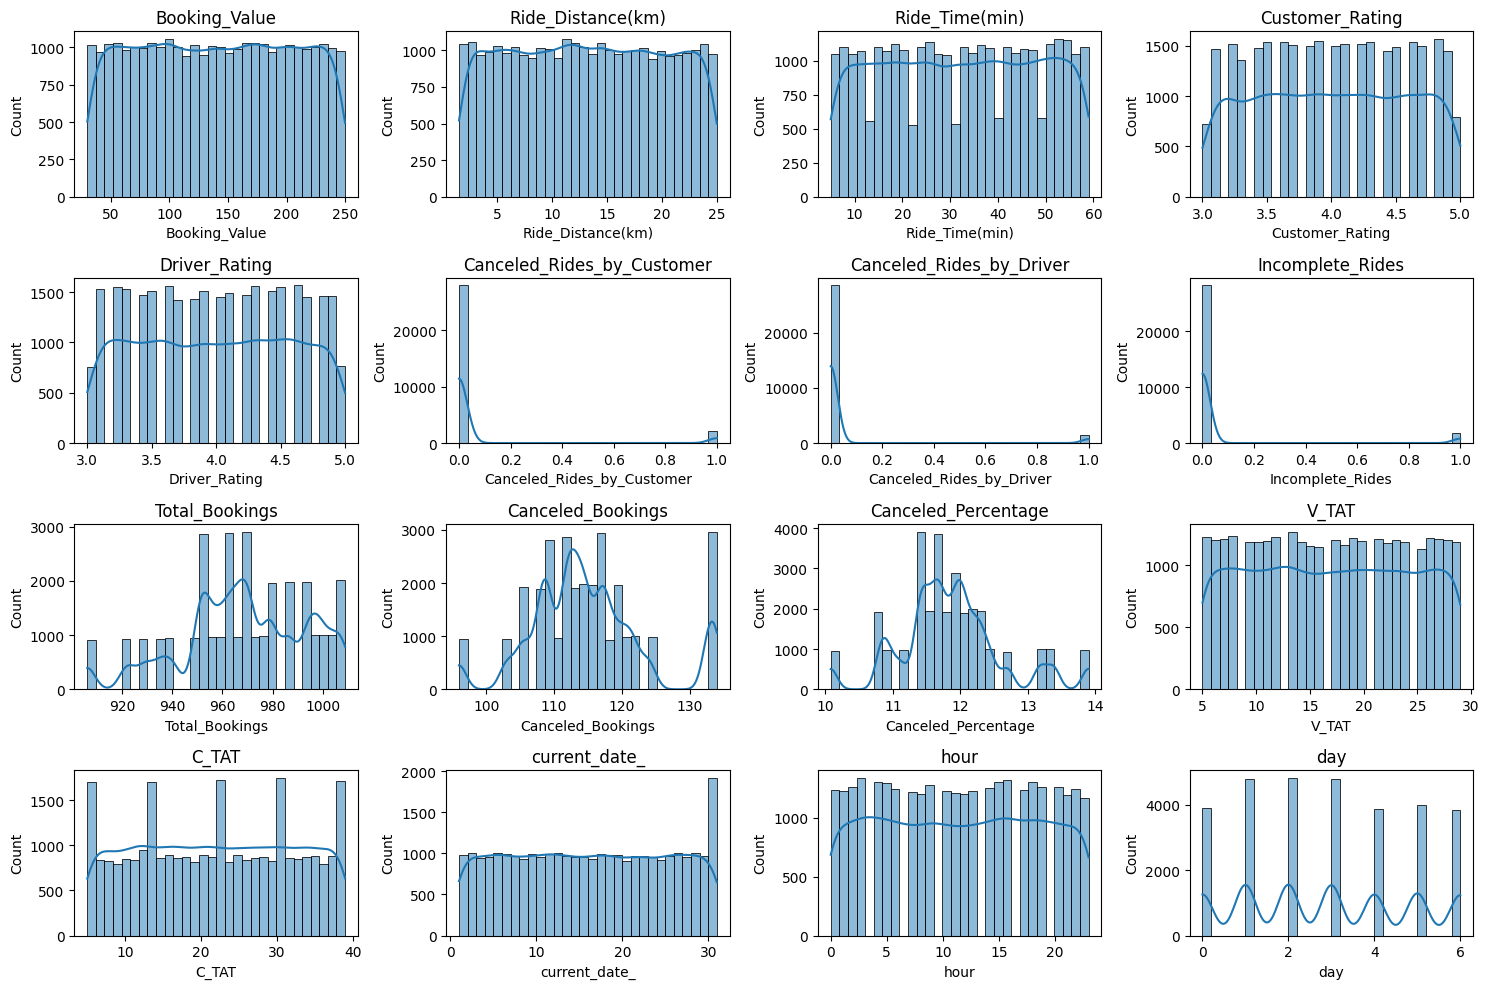

In [38]:
# distribution plot for numerical columns
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # adjust the number of rows and columns as needed
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

# Phase 1 : Booking conversation & volume

1 . What % of total bookings end as Completed vs Cancelled vs Incomplete — like checking how many people who "added to cart" actually paid? (Booking_Status value counts)

In [24]:
booking_status = pd.read_sql_query(text("""select Booking_Status , count(*) as total_people , round(count(*) * 100.0 / sum(count(*)) over(),2) as pct_of_total from clean_dataset group by Booking_Status order by total_people desc"""),engine)
display(booking_status)

,Booking_Status,total_people,pct_of_total
0,Completed,24641,82.14
1,Cancelled,3559,11.86
2,Incomplete,1800,6.00


2 . How does booking volume trend day-by-day across July — are weekends busier, like a restaurant doing more covers on Saturday? (Date)

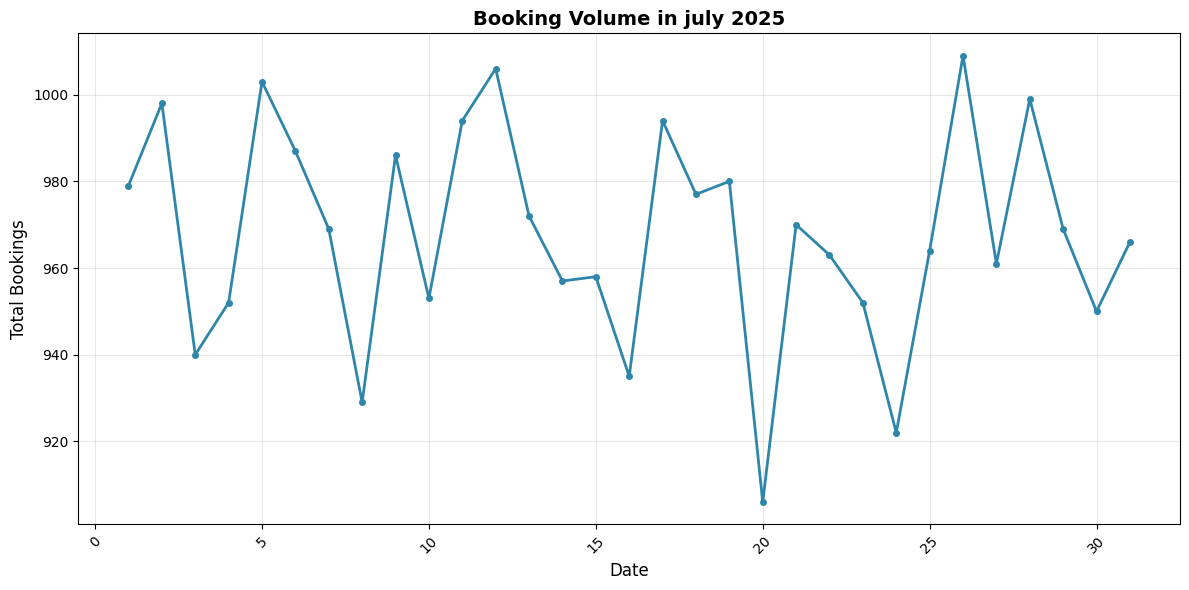

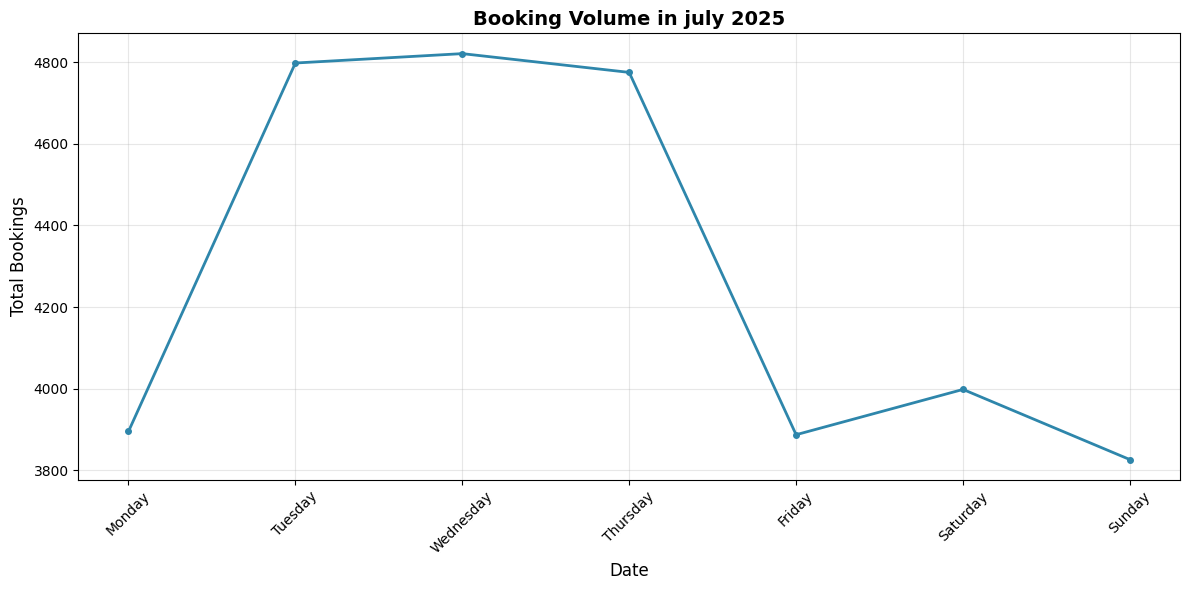

In [42]:
booking_volume = pd.read_sql_query(text("""select current_date_ , count(Booking_Value) as total_booking from clean_dataset group by current_date_ order by current_date_ """),engine)

weekday_volume =  pd.read_sql_query(text("""select day , day_name , count(Booking_Value) as total_booking from clean_dataset group by day , day_name order by day  """),engine)
# display(weekday_volume)

plt.figure(figsize=(12, 6))
plt.plot(booking_volume['current_date_'], booking_volume['total_booking'], 
         marker='o', linewidth=2, markersize=4, color='#2E86AB')

plt.title('Booking Volume in july 2025', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Bookings', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(weekday_volume['day_name'], weekday_volume['total_booking'], 
         marker='o', linewidth=2, markersize=4, color='#2E86AB')

plt.title('Booking Volume in july 2025', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Bookings', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

3. Which Vehicle_Type (Bike/Auto/Cab) drives the most bookings — your "best-selling product"?

In [45]:
vehical = pd.read_sql_query(text("""select Vehicle_Type , count(Booking_Value) as total_booking from clean_dataset group by Vehicle_Type order by total_booking desc """),engine)
display(vehical)

,Vehicle_Type,total_booking
0,Bike,21001
1,Auto,8999


4 . Which Pickup_Location (city) generates the highest booking volume — where should Rapido put more drivers, like a retailer deciding which store gets more stock?